In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier,GradientBoostingClassifier,StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [39]:
df=pd.read_csv('C:/Users/DHARSHINI/Downloads/sem5/machine-learning/experimemt-6/datasets/wdbc.data',header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [40]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print("\n\nNULL values :",df.isnull().sum().sum())


(569, 32)
Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype='int64')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       569 non-null    int64  
 1   1       569 non-null    object 
 2   2       569 non-null    float64
 3   3       569 non-null    float64
 4   4       569 non-null    float64
 5   5       569 non-null    float64
 6   6       569 non-null    float64
 7   7       569 non-null    float64
 8   8       569 non-null    float64
 9   9       569 non-null    float64
 10  10      569 non-null    float64
 11  11      569 non-null    float64
 12  12      569 non-null    float64
 13  13      569 non-null    float64
 14  14      569 non-null    float64
 15  15      569 non-null    float64
 16  16      569 non-null    float64
 17  17      569 n

## Class Distribution

In [41]:
def count_plot(col):
    plt.xlabel('Values')
    sns.countplot(x=col,data=df)
    plt.show()

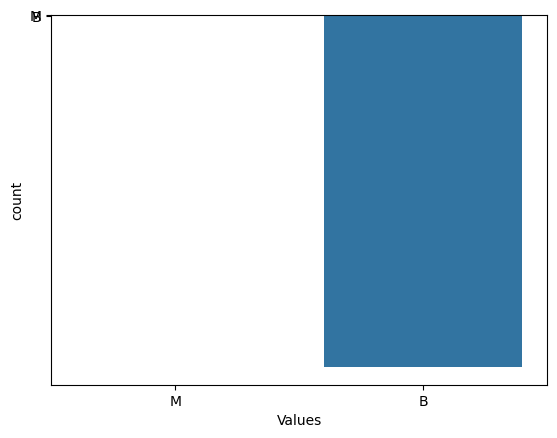

1
B    357
M    212
Name: count, dtype: int64

In [42]:
count_plot(df[1])
df[1].value_counts()

## Box plot

In [43]:
def box_plot(col):
    plt.figure(figsize=(5,5))
    sns.boxplot(x=df[col])
    plt.xlabel(col)
    plt.show()


In [44]:
def histogram(col):
    plt.figure(figsize=(5,5))
    df[col].hist()
    plt.xlabel(col)
    plt.show()

In [45]:
def correlation_analysis(columns):
    plt.figure(figsize=(15,15))
    sns.heatmap(columns.corr(),cmap='coolwarm')
    plt.show()

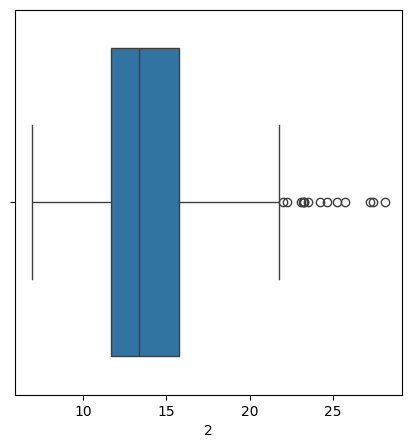

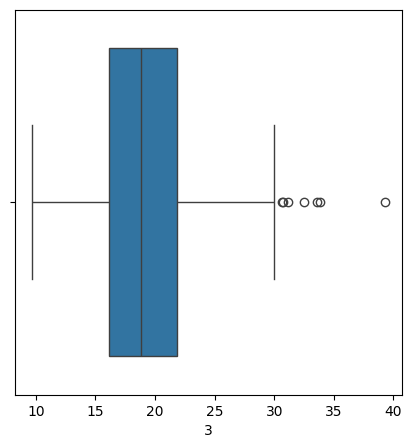

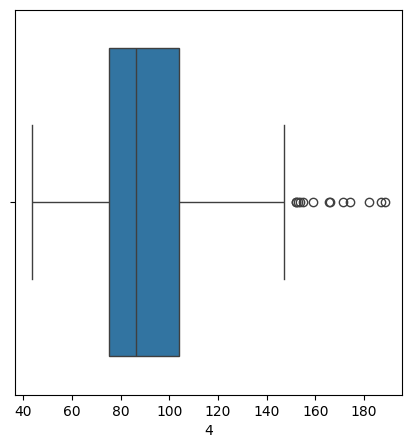

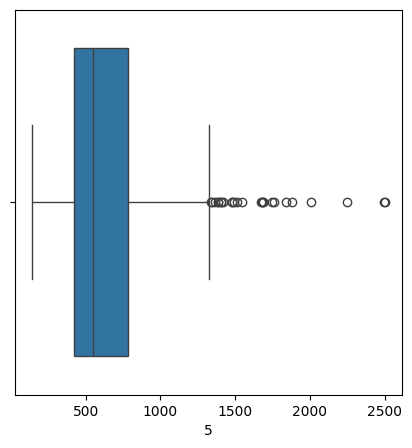

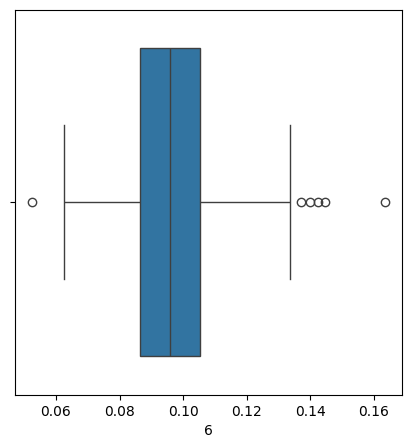

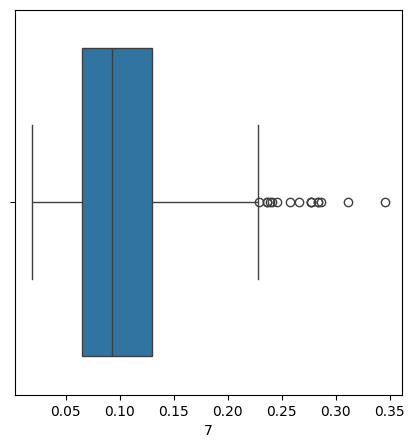

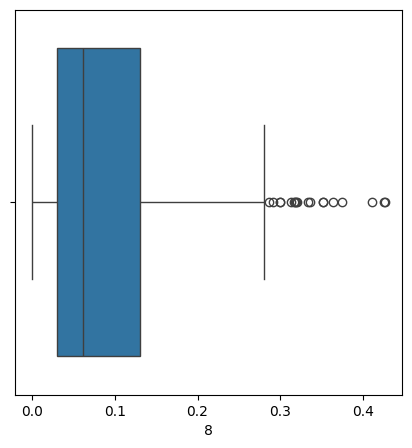

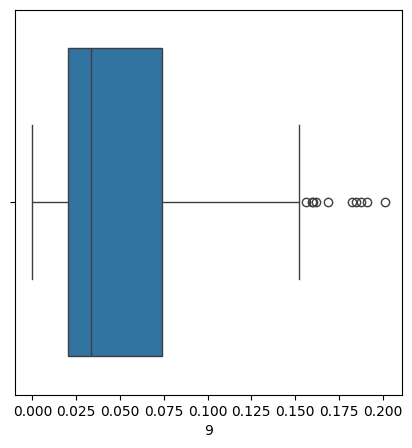

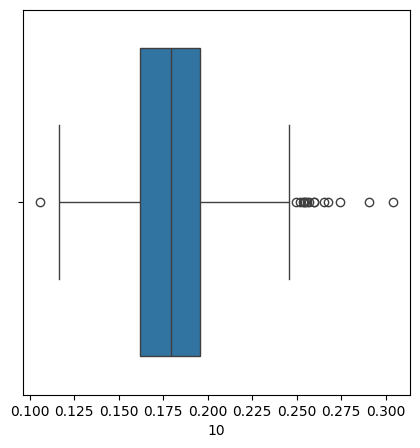

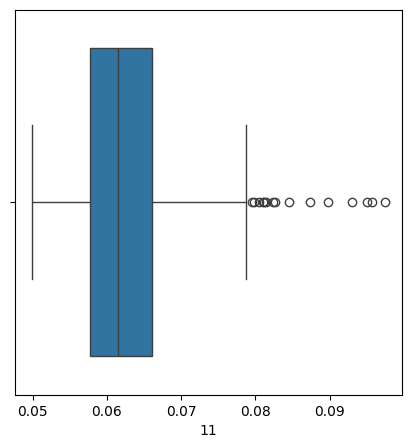

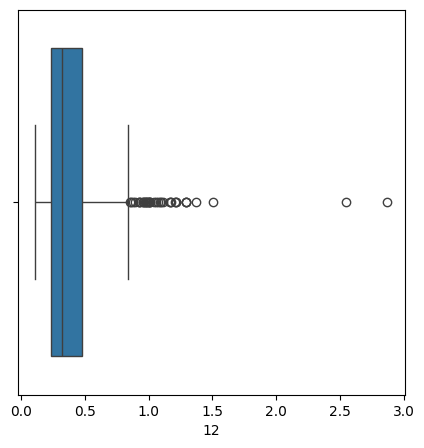

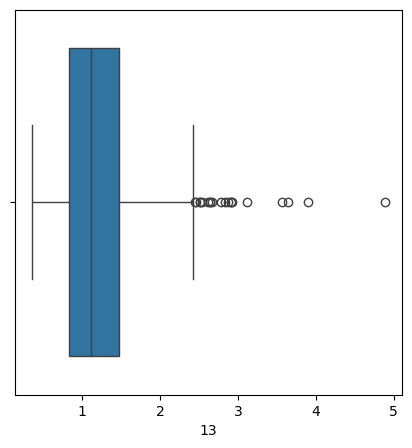

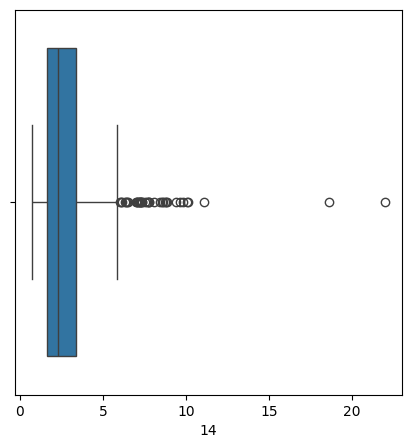

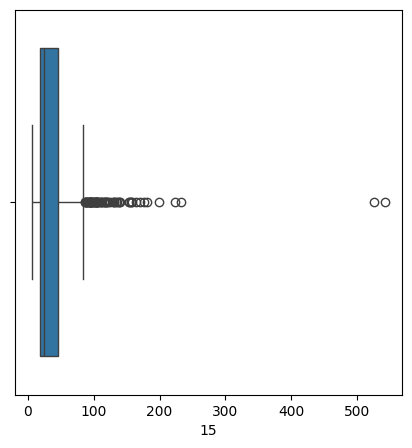

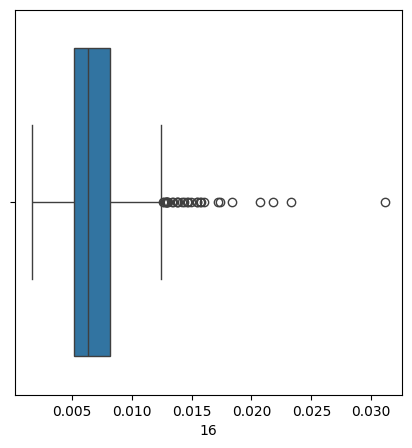

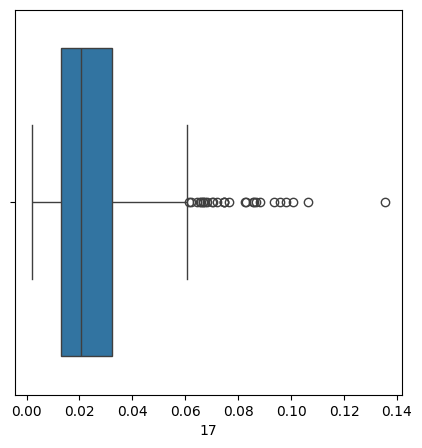

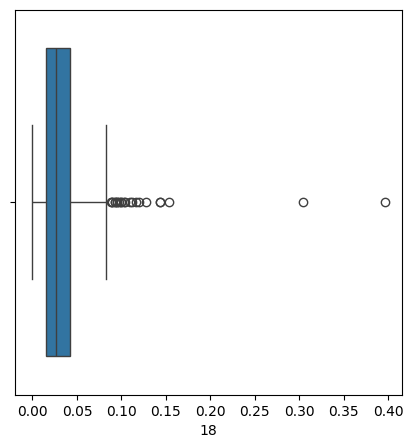

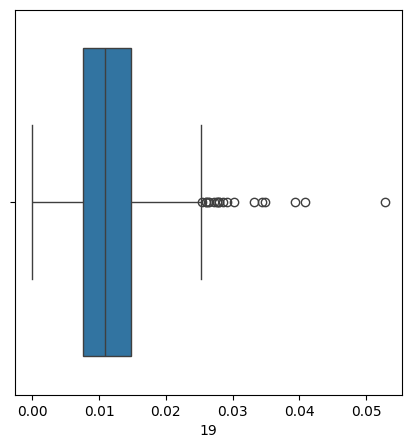

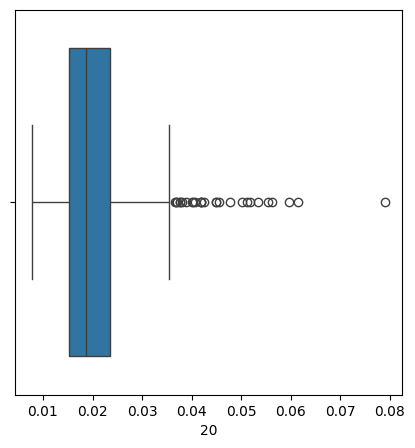

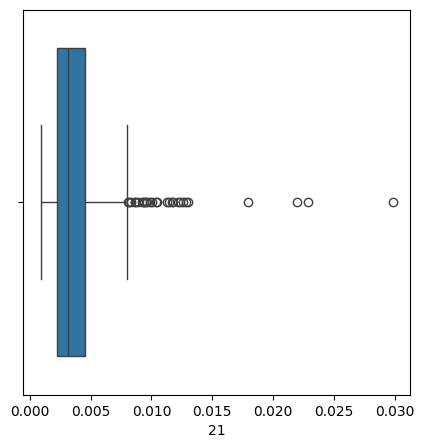

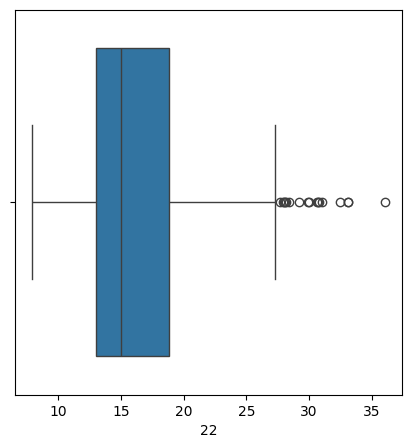

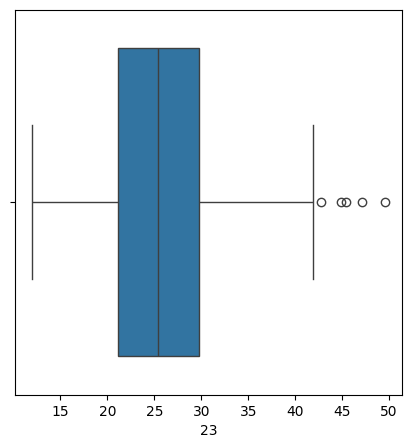

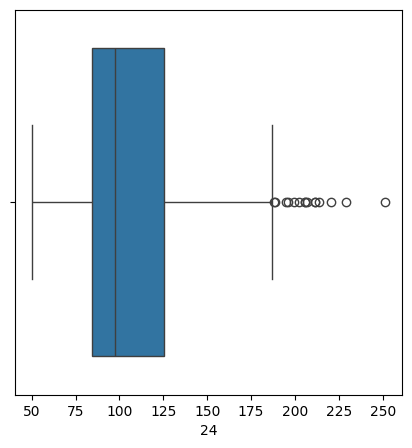

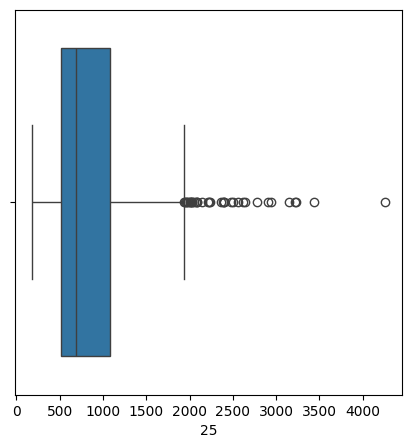

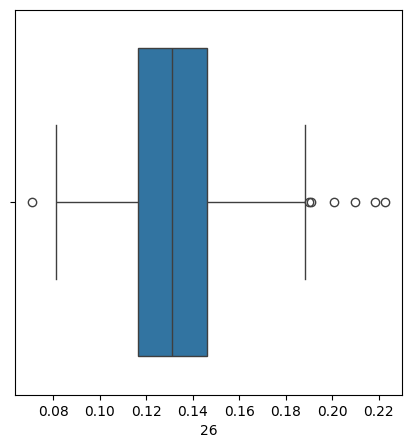

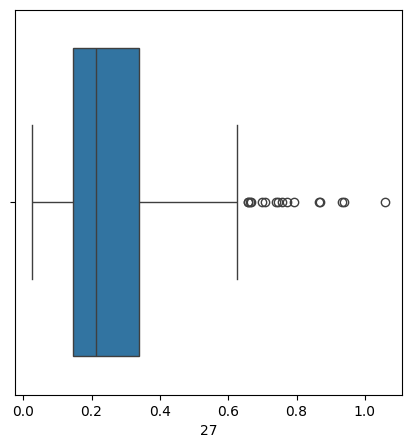

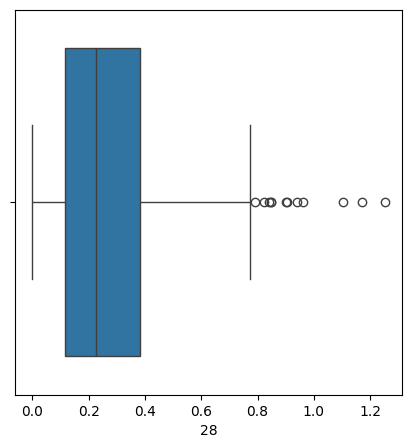

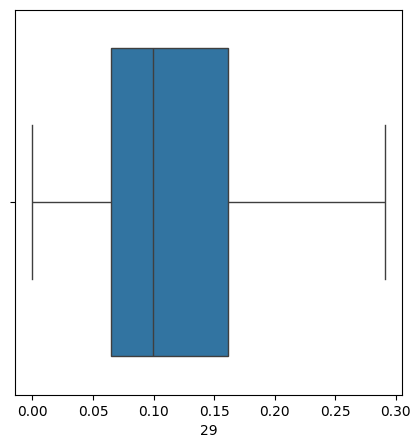

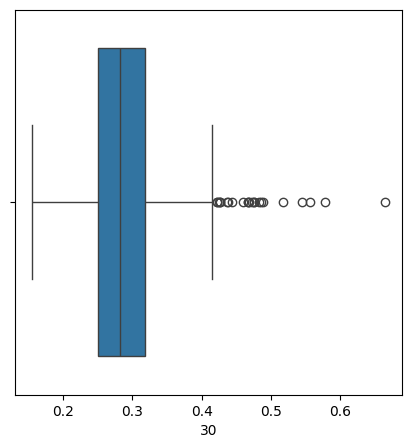

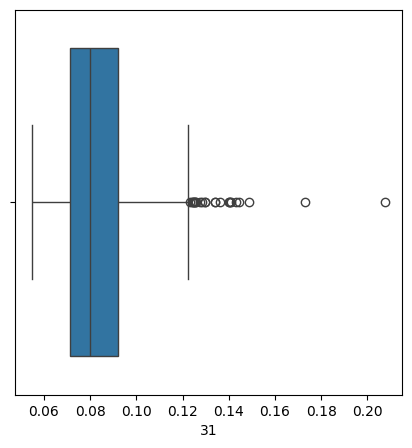

In [46]:
columns=df.drop(columns=[0,1])

for col in columns:
    box_plot(col)


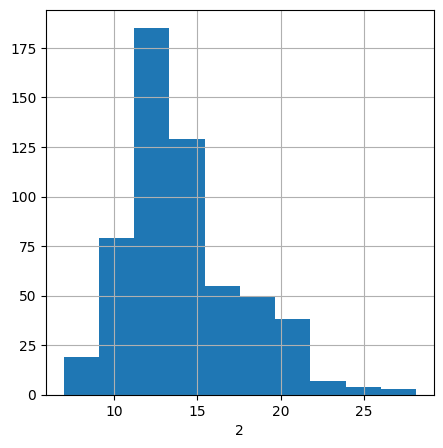

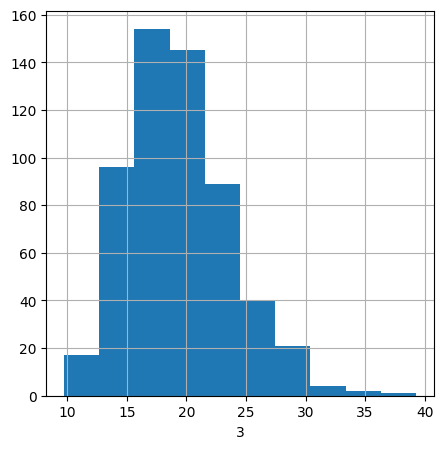

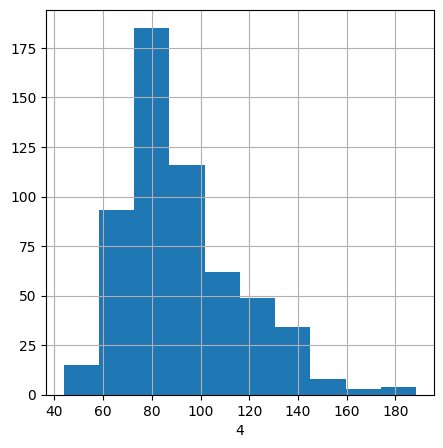

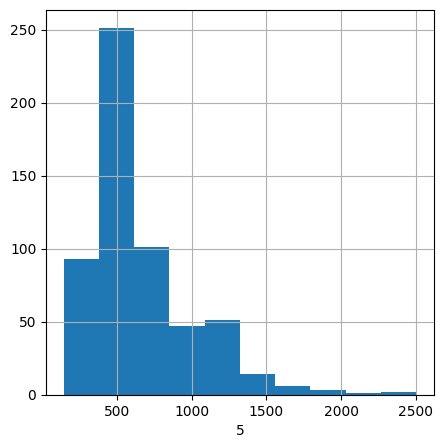

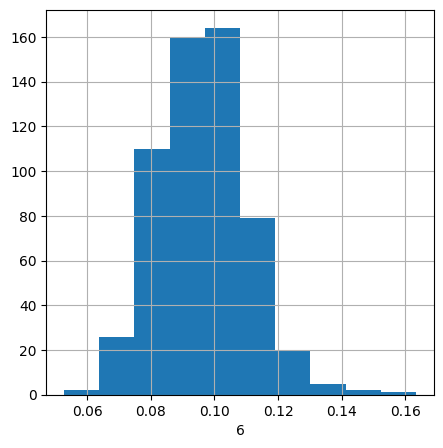

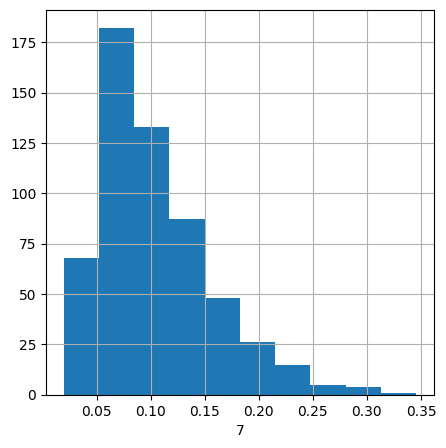

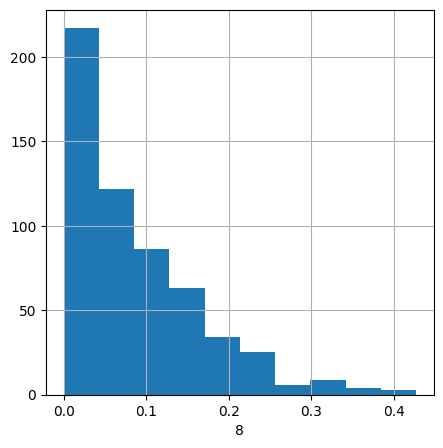

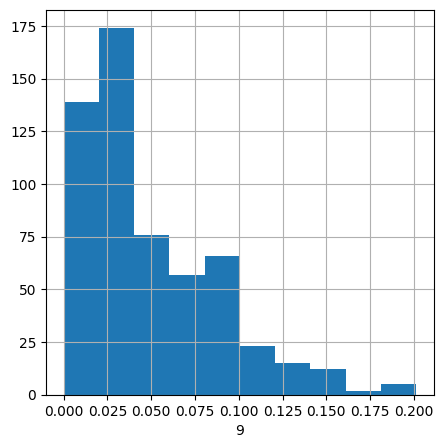

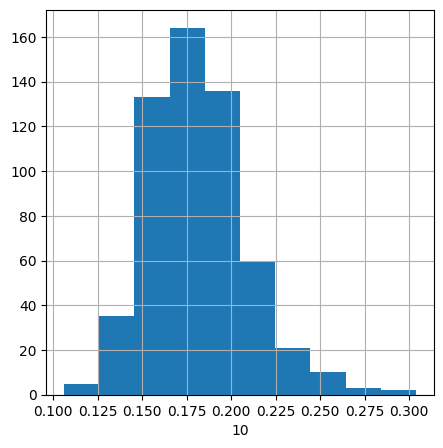

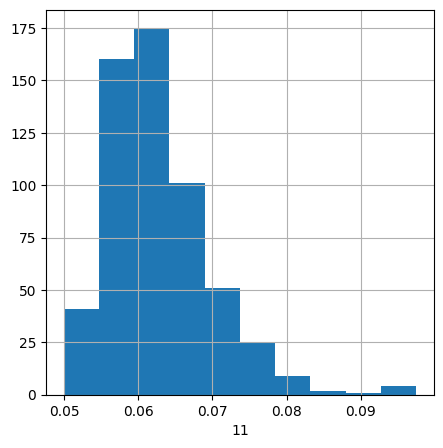

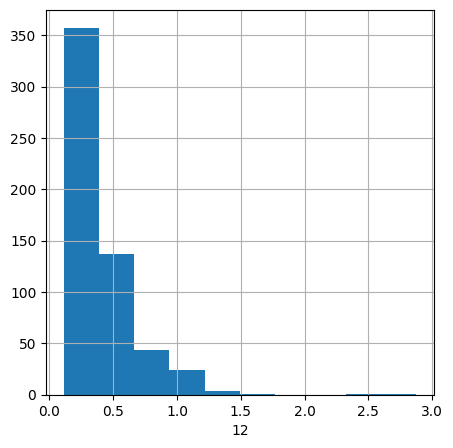

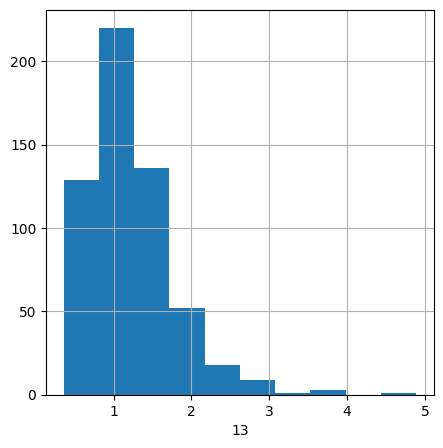

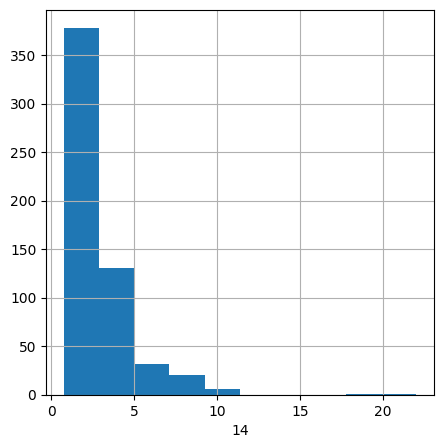

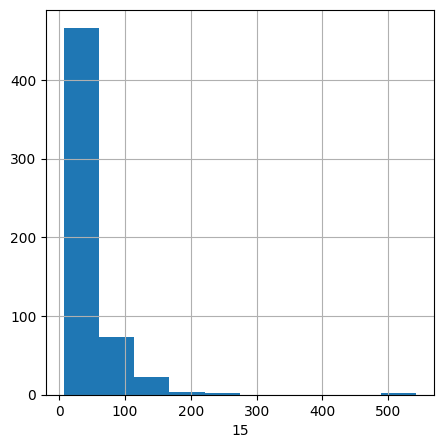

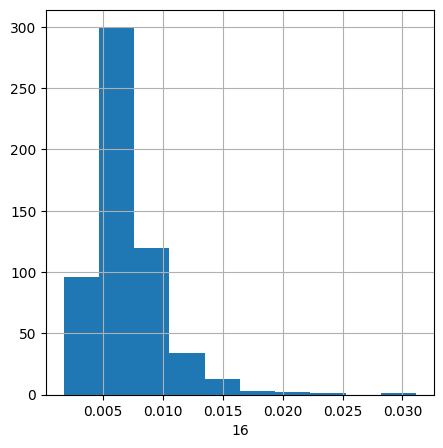

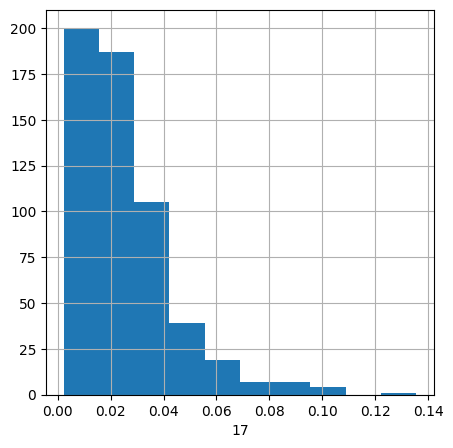

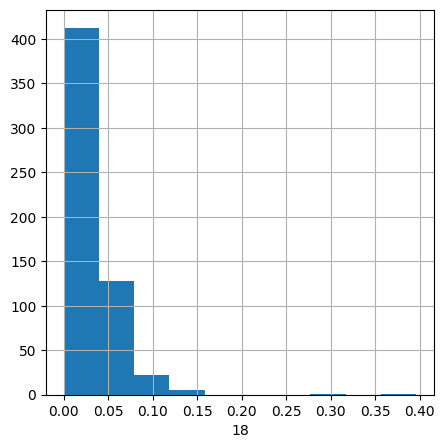

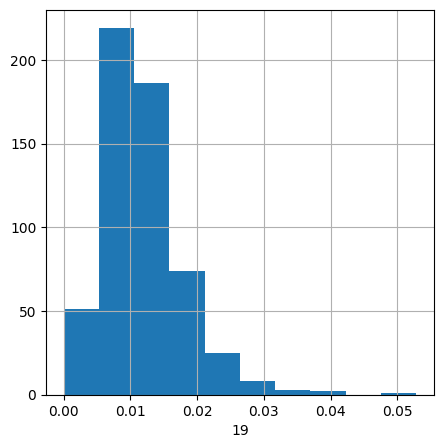

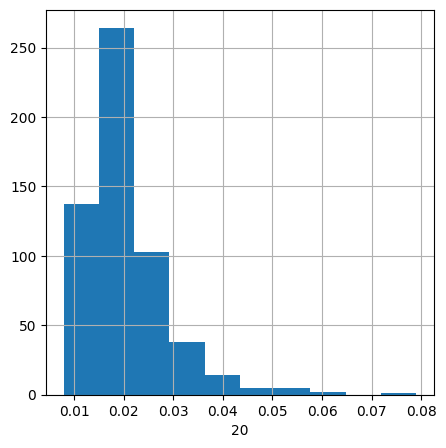

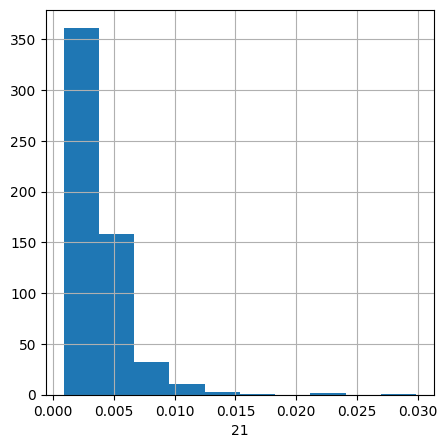

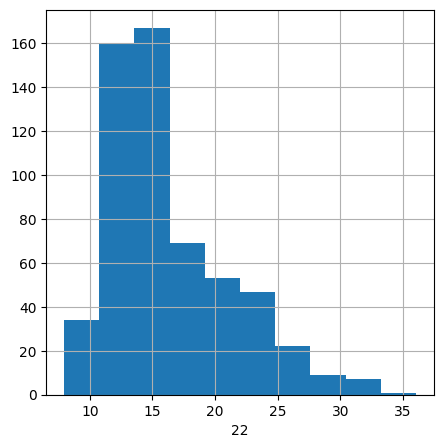

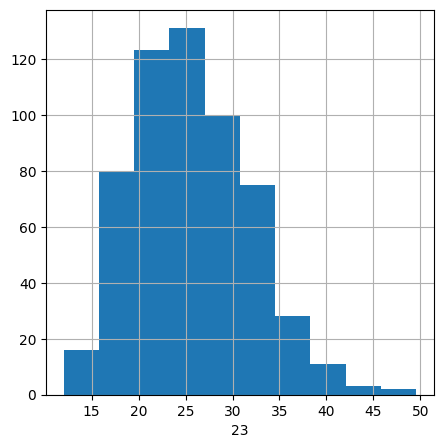

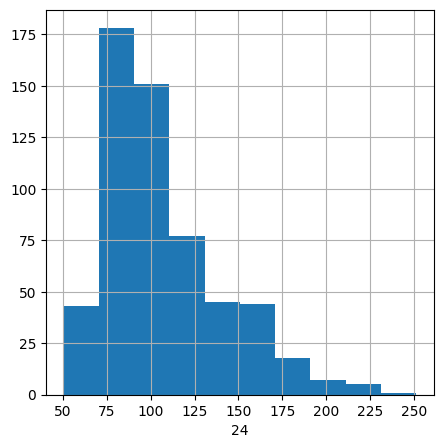

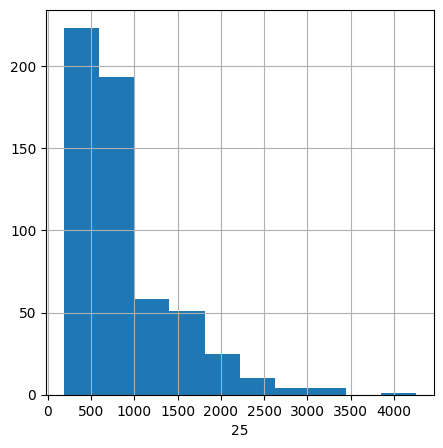

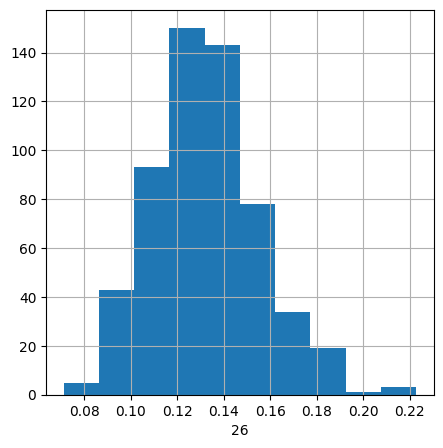

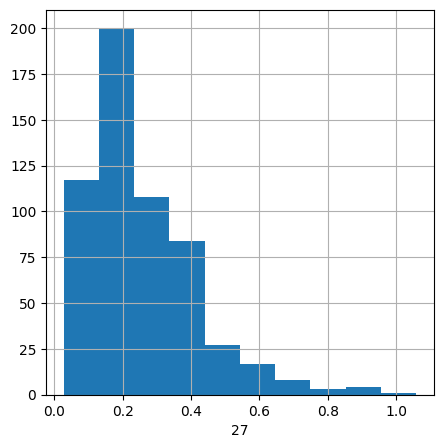

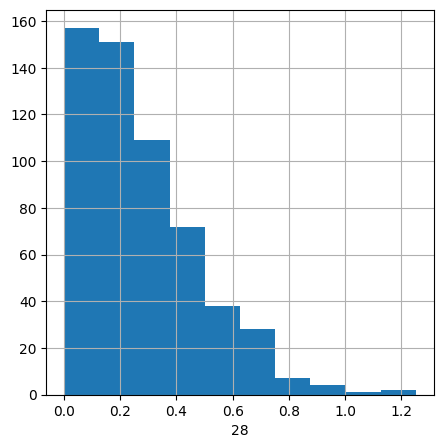

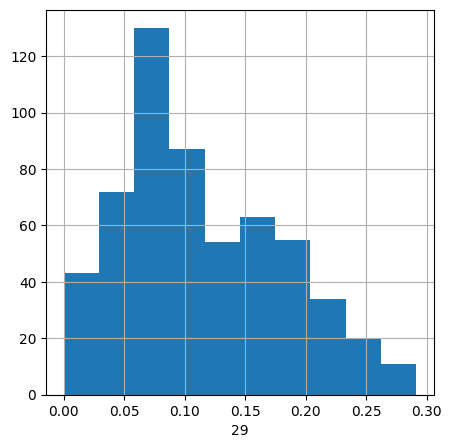

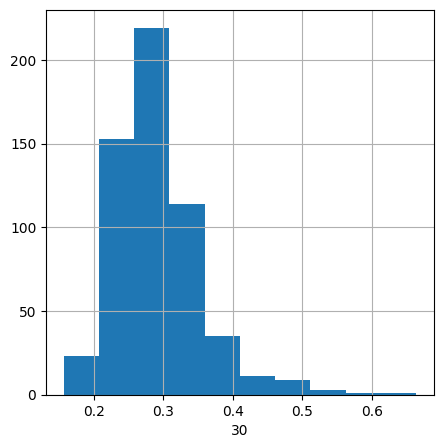

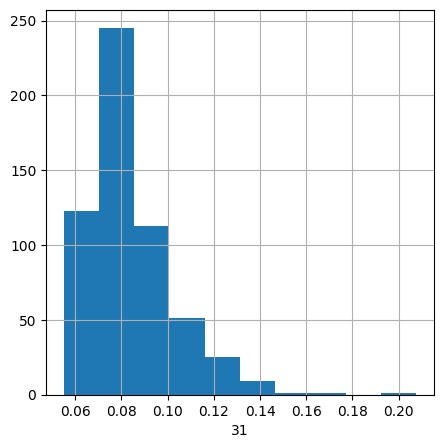

In [47]:
for col in columns:
    histogram(col)

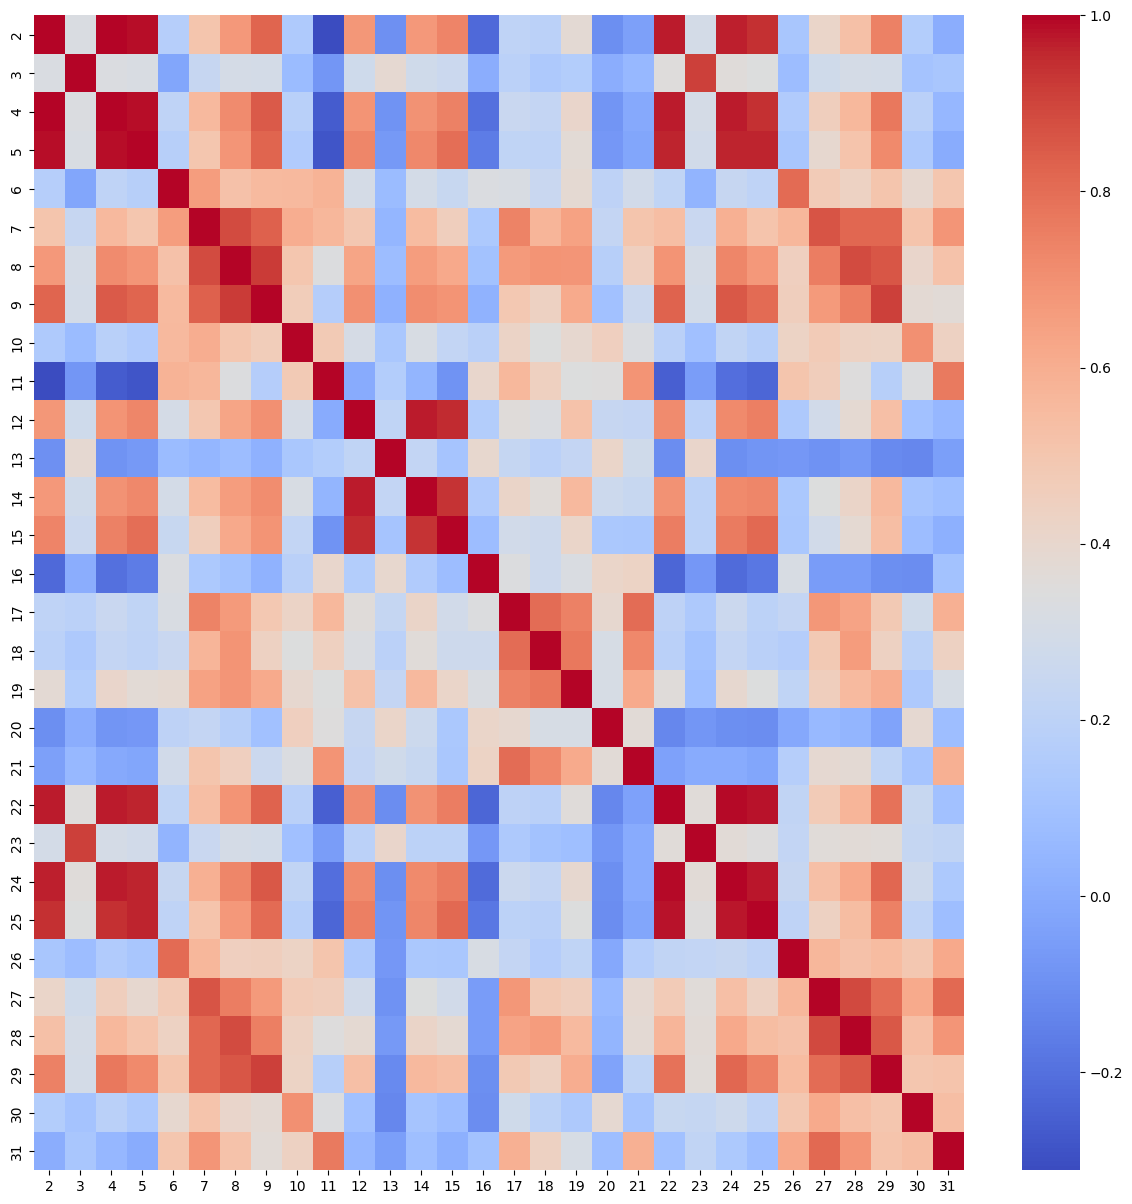

In [48]:
correlation_analysis(columns)

In [49]:
df[1]=df[1].map({
    'M':1,
    'B':0
})
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [50]:
x=df.drop(columns=[0,1])
y=df[1]

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [52]:
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_trnsformed=scaler.transform(x_test)

## Bagging

In [53]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42
)

param_grid = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0]
}

grid = GridSearchCV(
    bagging,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(x_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_features': 0.5, 'max_samples': 0.7, 'n_estimators': 50}
0.9692307692307693


## Ada Boost

In [54]:
ada = AdaBoostClassifier(
    random_state=42
)

param_grid = {
    'n_estimators':[50,60,70],
    'learning_rate':[0.01,0.1,1]
}

ada_grid = GridSearchCV(
    ada,
    param_grid,
    cv=5,
    scoring='accuracy'
)

ada_grid.fit(x_train,y_train)

best_ada = ada_grid.best_estimator_

print("Best Parameters:", ada_grid.best_params_)
print("Best Accuracy:", ada_grid.best_score_)


Best Parameters: {'learning_rate': 1, 'n_estimators': 60}
Best Accuracy: 0.964835164835165


## Gradient Boosting

In [55]:
gb = GradientBoostingClassifier(
    random_state=42
)

param_grid = {
    'n_estimators':[50,60,70],
    'learning_rate':[0.01,0.1,1],
    'max_depth':[1,3,5]
}

gb_grid = GridSearchCV(
    gb,
    param_grid,
    cv=5,
    scoring='accuracy'
)

gb_grid.fit(x_train,y_train)

print("Best Parameters:", gb_grid.best_params_)
print("Best Accuracy:", gb_grid.best_score_)

best_gb = gb_grid.best_estimator_

Best Parameters: {'learning_rate': 1, 'max_depth': 5, 'n_estimators': 50}
Best Accuracy: 0.9670329670329672


##  

In [56]:
base_models = [
    ('svm', SVC(probability=True)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier())
]

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression()
)

stack_model.fit(x_train_scaled, y_train)

StackingClassifier(estimators=[('svm', SVC(probability=True)),
                               ('nb', GaussianNB()),
                               ('dt', DecisionTreeClassifier())],
                   final_estimator=LogisticRegression())

In [57]:
results = []

def evaluate(model, X_test, y_test, name):

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n", name)
    print("Accuracy :", accuracy)
    print("Precision :", precision)
    print("Recall :", recall)
    print("F1 Score :", f1)
    print("Confusion Matrix")
    
    print(confusion_matrix(y_test, y_pred))

    return [name, accuracy, precision, recall, f1]

In [62]:
results.append(
    evaluate(
        grid,
        x_test,
        y_test,
        "Bagging"
    )
)
results.append(
    evaluate(
        best_ada,
        x_test,
        y_test,
        "AdaBoost"
    )
)
results.append(
    evaluate(
        best_gb,
        x_test,
        y_test,
        "Gradient Boosting"
    )
)
results.append(
    evaluate(
        stack_model,
        x_test_trnsformed,
        y_test,
        "Stacking"
    )
)


 Bagging
Accuracy : 0.9649122807017544
Precision : 1.0
Recall : 0.9047619047619048
F1 Score : 0.95
Confusion Matrix
[[72  0]
 [ 4 38]]

 AdaBoost
Accuracy : 0.9824561403508771
Precision : 1.0
Recall : 0.9523809523809523
F1 Score : 0.975609756097561
Confusion Matrix
[[72  0]
 [ 2 40]]

 Gradient Boosting
Accuracy : 0.9649122807017544
Precision : 0.975
Recall : 0.9285714285714286
F1 Score : 0.9512195121951219
Confusion Matrix
[[71  1]
 [ 3 39]]

 Stacking
Accuracy : 0.9649122807017544
Precision : 1.0
Recall : 0.9047619047619048
F1 Score : 0.95
Confusion Matrix
[[72  0]
 [ 4 38]]


## Comparision Table

In [63]:
comparison_table = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Bagging,0.964912,1.000,0.904762,0.95000
1,AdaBoost,0.982456,1.000,0.952381,0.97561
2,Gradient Boosting,0.964912,0.975,0.928571,0.95122
3,Stacking,0.964912,1.000,0.904762,0.95000


## ROC curve

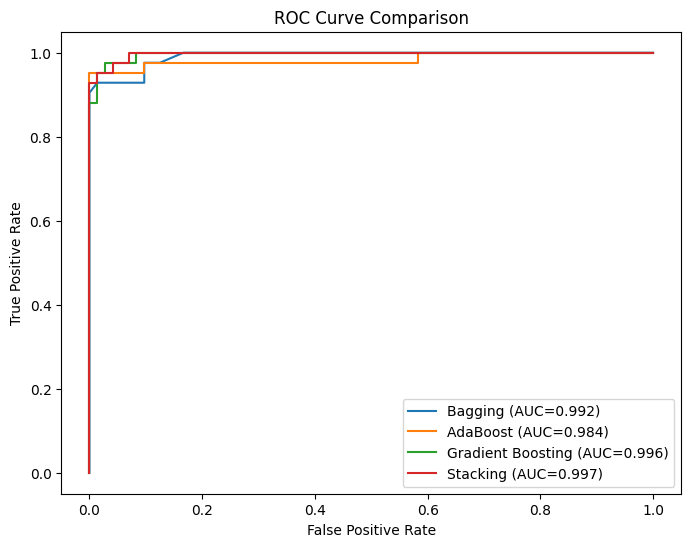

In [68]:
models = [
    (grid, x_test, "Bagging"),
    (best_ada, x_test, "AdaBoost"),
    (best_gb, x_test, "Gradient Boosting"),
    (stack_model, x_test_trnsformed, "Stacking")
]

plt.figure(figsize=(8,6))

for model, X_eval, name in models:

    probs = model.predict_proba(X_eval)[:,1]

    fpr, tpr, _ = roc_curve(y_test, probs)

    auc = roc_auc_score(y_test, probs)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.show()